In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import joblib

In [79]:
from google.colab import files

uploaded = files.upload()

Saving final_test_processed.csv to final_test_processed (2).csv
Saving final_train_processed.csv to final_train_processed (7).csv


In [80]:
import pandas as pd

df = pd.read_csv("final_train_processed.csv")
df = pd.read_csv("final_test_processed.csv")

print(df.shape)
df.head()

(1914, 18)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance,Exited
0,0.196483,0,0.193211,1.394672,-1.341260,0.878882,0,0,0.615301,0,0,-0.034391,0.961455,-1.195658,-0.458065,0,1,0
1,1.130834,1,-1.182269,0.011320,0.353342,0.878882,0,1,-0.244237,1,0,-0.028813,0.474536,-0.288717,-0.063557,0,0,0
2,0.637989,0,-1.182269,0.702996,1.066331,-0.772148,1,1,-0.268687,1,0,-0.026335,1.276520,1.381400,-0.679976,1,0,0
3,0.196483,1,-1.605493,-1.372033,1.240514,-0.772148,0,0,-1.094971,0,0,-0.014848,-1.065275,1.567844,0.429578,0,0,1
4,-0.265559,0,-0.441626,-1.717871,-1.341260,0.878882,1,0,0.196402,0,1,-0.034391,-1.530426,-1.195658,4.867794,0,1,0


In [81]:
# Separate features and target
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1914, 17)
Target shape: (1914,)


In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1531, 17)
Testing set: (383, 17)


In [83]:
random_state=42

In [84]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [85]:
# Train the model
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

XGBoost training completed!


In [86]:
y_pred = xgb_model.predict(X_test)

In [87]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

In [88]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("XGBoost Results")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

XGBoost Results
-------------------------
Accuracy : 0.8642
Precision: 0.7069
Recall   : 0.5395
F1 Score : 0.6119
ROC-AUC  : 0.9024


In [89]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       307
           1       0.71      0.54      0.61        76

    accuracy                           0.86       383
   macro avg       0.80      0.74      0.76       383
weighted avg       0.86      0.86      0.86       383



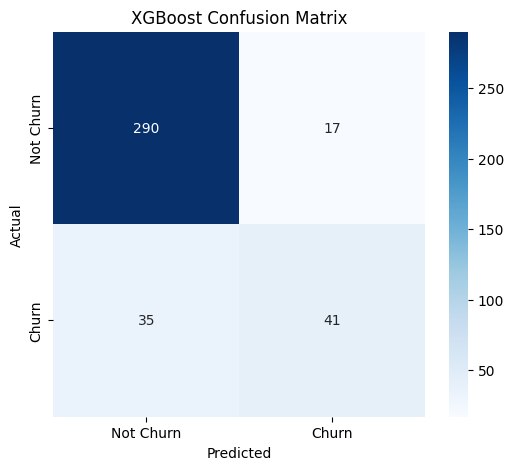

In [90]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

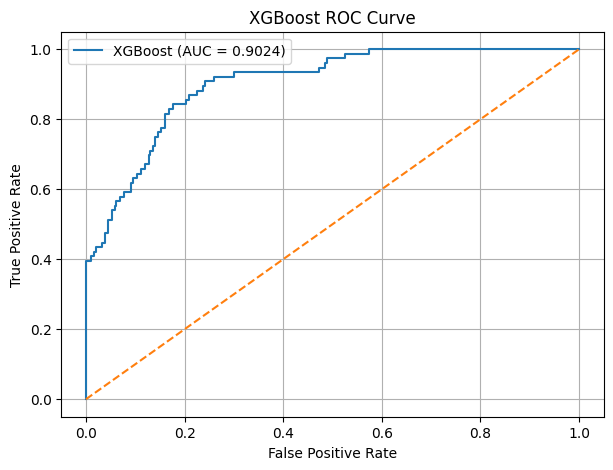

In [91]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [92]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
5        NumOfProducts    0.191004
7       IsActiveMember    0.100587
2                  Age    0.088446
9    Geography_Germany    0.084408
1               Gender    0.052510
4              Balance    0.051352
15      ActiveWithCard    0.049392
13   BalancePerProduct    0.045321
11  BalanceSalaryRatio    0.044087
3               Tenure    0.041104
0          CreditScore    0.040230
10     Geography_Spain    0.040015
8      EstimatedSalary    0.039876
12         TenureByAge    0.039376
14   ProductsPerTenure    0.038805
6            HasCrCard    0.033479
16       IsZeroBalance    0.020007


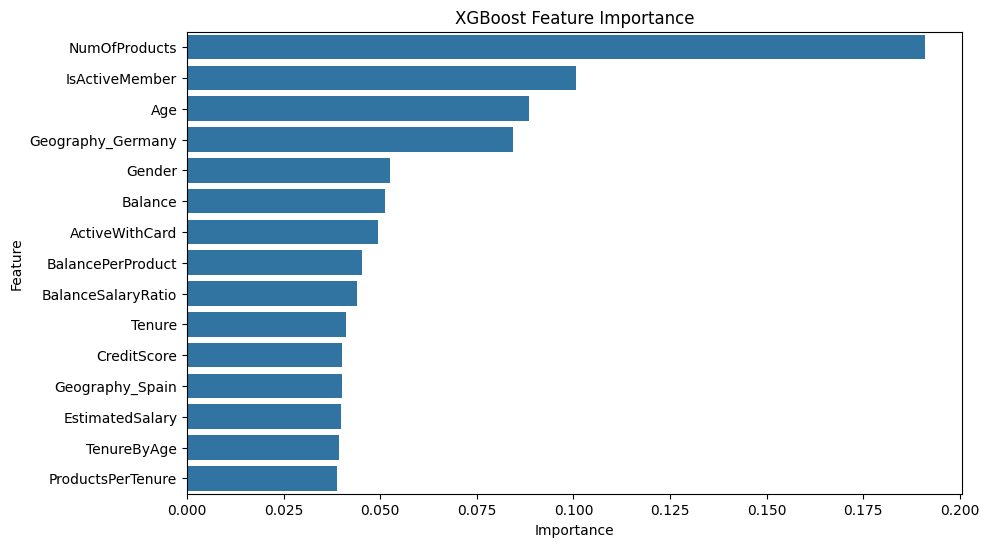

In [93]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.show()

In [94]:
joblib.dump(
    xgb_model,
    "xgboost_model.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [95]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

xgb_results.to_csv(
    "xgboost_results.csv",
    index=False
)

print(xgb_results)

     Model  Accuracy  Precision    Recall  F1_Score   ROC_AUC
0  XGBoost   0.86423   0.706897  0.539474   0.61194  0.902366


In [96]:
xgb_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_pred_proba
})

xgb_predictions.to_csv(
    "xgboost_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [97]:
xgb_results = pd.read_csv("xgboost_results.csv")